In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
import os
import pynbody
import pynbody.plot.sph as sph
import pyarrow

SMALLSIZE = 9
NORMALSIZE = 9
LARGESIZE = 9

params = {
    "font.family":"serif",
    "mathtext.fontset":"stix",
    "font.size": SMALLSIZE,
    "axes.titlesize" : SMALLSIZE,
    "axes.labelsize" : NORMALSIZE,
    'xtick.labelsize': SMALLSIZE,
    'ytick.labelsize': SMALLSIZE,      
    'legend.fontsize': SMALLSIZE,  
    'figure.titlesize': LARGESIZE,
    'pgf.texsystem' : "pdflatex"
}
matplotlib.rcParams.update(params)

isob_dir = "../data/IsoB_dt10_all"
snap_names = [f"GLX.000{10*(j):03.0f}" for j in range(1, 62)] + [f"GLX.0{10*j:04.0f}" for j in range(62, 101)]


In [144]:
for i, snap in enumerate(snap_names):
    if i < 95:
        continue

    sim = pynbody.load(f"{isob_dir}/{snap}")
    sim.physical_units()
    pynbody.analysis.angmom.faceon(sim)
    df = pd.DataFrame(dict(
        iord = sim.s['iord'],
        x = sim.s['x'],
        y = sim.s['y'],
        z = sim.s['z'],
        mass = sim.s['mass']
    ))
    text = snap.split(".")
    df.to_csv(f"../data/IsoB_dt10_stars/{text[0]}.0{text[1]}.csv")
    print(i)

95
96
97
98
99


In [ ]:

print(csv_names)

['GLX.000010', 'GLX.000020', 'GLX.000030', 'GLX.000040', 'GLX.000050', 'GLX.000060', 'GLX.000070', 'GLX.000080', 'GLX.000090', 'GLX.000100', 'GLX.000110', 'GLX.000120', 'GLX.000130', 'GLX.000140', 'GLX.000150', 'GLX.000160', 'GLX.000170', 'GLX.000180', 'GLX.000190', 'GLX.000200', 'GLX.000210', 'GLX.000220', 'GLX.000230', 'GLX.000240', 'GLX.000250', 'GLX.000260', 'GLX.000270', 'GLX.000280', 'GLX.000290', 'GLX.000300', 'GLX.000310', 'GLX.000320', 'GLX.000330', 'GLX.000340', 'GLX.000350', 'GLX.000360', 'GLX.000370', 'GLX.000380', 'GLX.000390', 'GLX.000400', 'GLX.000410', 'GLX.000420', 'GLX.000430', 'GLX.000440', 'GLX.000450', 'GLX.000460', 'GLX.000470', 'GLX.000480', 'GLX.000490', 'GLX.000500', 'GLX.000510', 'GLX.000520', 'GLX.000530', 'GLX.000540', 'GLX.000550', 'GLX.000560', 'GLX.000570', 'GLX.000580', 'GLX.000590', 'GLX.000600', 'GLX.000610', 'GLX.000620', 'GLX.000630', 'GLX.000640', 'GLX.000650', 'GLX.000660', 'GLX.000670', 'GLX.000680', 'GLX.000690', 'GLX.000700', 'GLX.000710', 'GLX.

In [ ]:
aa = os.listdir("../data/IsoB_dt10_stars")
csv_names = snap_names = [f"GLX.00{10*(j):04.0f}" for j in range(1, 101)]




#print(aa)
for i in csv_names:
    df = pd.read_csv(f"../data/IsoB_dt10_stars/{i}.csv")
    df['rz'] = np.sqrt(df['x']**2 + df['y']**2)
    df['phiz'] = np.atan2(df['y'], df['x'])
    df[['iord', 'x', 'y', 'z', 'rz', 'phiz', 'mass']].to_parquet(f"../data/stars/{i}.parquet", engine="pyarrow", compression='snappy')
    print(i)


GLX.001000


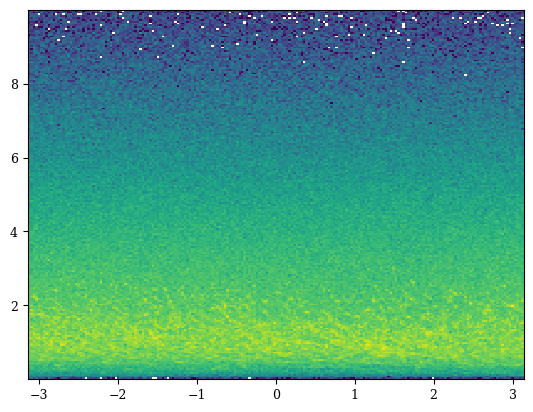

In [38]:
df = pd.read_parquet("../data/stars/GLX.000020.parquet")

fig, ax = plt.subplots()
df = df[df['rz'] < 10]
ax.hist2d(df['phiz'], df['rz'], norm='log', bins=200);